### Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import openpyxl

import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
datos = pd.read_csv('datos_preprocesados_train_final_smote.csv')
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            577 non-null    int64  
 1   mts2                  577 non-null    float64
 2   dormitorios           577 non-null    float64
 3   parqueos              577 non-null    float64
 4   banos                 577 non-null    float64
 5   CANT_HOSPITAL         577 non-null    float64
 6   CANT_SUPERMERCADO     577 non-null    float64
 7   hogares_lectura       577 non-null    float64
 8   hogares_techo_lamina  577 non-null    float64
 9   hogares_sin_agua      577 non-null    float64
 10  miembros_ph_avg       577 non-null    float64
 11  cnt_habit_ph_med      577 non-null    float64
 12  tipo_vivienda_avg     577 non-null    float64
 13  tipo_vivienda_le      577 non-null    int64  
 14  DEPTO_le              577 non-null    int64  
 15  DEPTO_avg             5

In [7]:
datos2 = pd.read_csv('datos_preprocesados_depurados_final.csv')
datos2['zona2'] = np.where(datos2['nom_dpto'].isin(['AHUACHAPÁN', 'LA PAZ', 'LA UNIÓN','MORAZÁN','SONSONATE','USULUTÁN']),0,
                           np.where(datos2['nom_dpto'].isin(['SAN SALVADOR', 'LA LIBERTAD']),1,2))
datos3 = datos2[datos2['flag_train']==1]
datos2 = datos2[datos2['flag_train']==0]
datos2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 184 entries, 429 to 612
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            184 non-null    int64  
 1   mts2                  184 non-null    float64
 2   dormitorios           184 non-null    float64
 3   parqueos              184 non-null    float64
 4   banos                 184 non-null    float64
 5   CANT_HOSPITAL         184 non-null    float64
 6   CANT_SUPERMERCADO     184 non-null    float64
 7   hogares_lectura       184 non-null    float64
 8   hogares_techo_lamina  184 non-null    float64
 9   hogares_sin_agua      184 non-null    float64
 10  miembros_ph_avg       184 non-null    float64
 11  cnt_habit_ph_med      184 non-null    float64
 12  flag_train            184 non-null    int64  
 13  tipo_vivienda_avg     184 non-null    float64
 14  tipo_vivienda_le      184 non-null    int64  
 15  DEPTO_le              184 

In [8]:
pd.crosstab(index = datos2.nom_dpto, columns = datos2.zona2)

zona2,0,1,2
nom_dpto,,,
AHUACHAPÁN,12,0,0
CHALATENANGO,0,0,5
CUSCATLÁN,0,0,1
LA LIBERTAD,0,35,0
LA PAZ,11,0,0
LA UNIÓN,1,0,0
MORAZÁN,1,0,0
SAN MIGUEL,0,0,19
SAN SALVADOR,0,62,0


In [10]:
datos3.zona2.value_counts()

,count
zona2,
1,232
2,103
0,94


In [11]:
datos.columns

Index(['Unnamed: 0', 'mts2', 'dormitorios', 'parqueos', 'banos',
       'CANT_HOSPITAL', 'CANT_SUPERMERCADO', 'hogares_lectura',
       'hogares_techo_lamina', 'hogares_sin_agua', 'miembros_ph_avg',
       'cnt_habit_ph_med', 'tipo_vivienda_avg', 'tipo_vivienda_le', 'DEPTO_le',
       'DEPTO_avg', 'zona_le', 'zona_avg', 'nom_dpto_le', 'nom_dpto_avg',
       'nom_mun_le', 'nom_mun_avg', 'precio', 'perfil'],
      dtype='object')

In [12]:
atributos = [x for x in datos.columns if x not in ['Unnamed: 0','precio','perfil','DEPTO_le','DEPTO_avg','nom_dpto_le', 'nom_dpto_avg','nom_mun_le', 'nom_mun_avg']]

In [13]:
X = datos[atributos]
y = datos['precio']

In [14]:
cols_nas = pd.DataFrame(datos2[atributos].isna().mean()).reset_index()
cols_nas.columns = ['Variable', 'nulos']
cols_nas[cols_nas['nulos']>0].sort_values(by='nulos',ascending=False)

,Variable,nulos


In [15]:
cols_nas = pd.DataFrame(datos[atributos].isna().mean()).reset_index()
cols_nas.columns = ['Variable', 'nulos']
cols_nas[cols_nas['nulos']>0].sort_values(by='nulos',ascending=False)

,Variable,nulos


# Definición de funciones

In [16]:
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score

def metricas(y_true, y_pred):
    resultados = {}
    resultados['RMSE'] = rmse(y_true, y_pred)
    resultados['MAPE'] = mape(y_true, y_pred)
    resultados['R2'] = r2_score(y_true, y_pred)

    # Evitar división por cero
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    error = (y_pred - y_true) / y_true

    resultados['Mediana_ErrorAbs'] = np.median(np.abs(error))
    resultados['Pct_Error<0.3'] = np.sum(np.abs(error) <= 0.3) / len(error)
    return resultados



In [46]:

def analisis_deciles(y_true, y_pred, n_deciles=10, umbral=0.3, tipo = 'real'):
    """
    Evalúa el desempeño del modelo por deciles de y_true.

    Parámetros:
    -----------
    y_true : array-like
        Valores reales.
    y_pred : array-like
        Valores predichos.
    n_deciles : int, opcional (default=10)
        Número de segmentos (deciles por defecto).
    umbral : float, opcional (default=0.3)
        Umbral de error relativo (30% por defecto).

    Retorna:
    --------
    DataFrame con columnas:
        - Decil
        - y_true_min, y_true_max: rango del decil
        - %Subestimado (> +umbral)
        - %Error<umbral
        - %Sobreestimado (< -umbral)
    """

    # Convertir a DataFrame para facilidad
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}).copy()

    # Evitar división por cero
    df['y_true_safe'] = np.where(df['y_true'] == 0, np.finfo(float).eps, df['y_true'])

    # Error relativo
    df['error_rel'] = (df['y_pred'] - df['y_true']) / df['y_true_safe']

    # Crear deciles de y_true
    if tipo == 'real':
        df['decil'] = pd.qcut(df['y_true'], q=n_deciles, labels=False, duplicates='drop') + 1
    else:
      df['decil'] = pd.qcut(df['y_pred'], q=n_deciles, labels=False, duplicates='drop') + 1

    # Calcular métricas por decil
    resumen = df.groupby('decil').apply(lambda x: pd.Series({
        'conteo': x['y_true'].size,
        'y_true_min': x['y_true'].min(),
        'y_true_max': x['y_true'].max(),
        '%Subestimado(>+{:.0f}%)'.format(umbral*100): np.mean(x['error_rel'] > umbral) * 100,
        '%Error<={:.0f}%'.format(umbral*100): np.mean(np.abs(x['error_rel']) <= umbral) * 100,
        '%Sobreestimado(<-{:.0f}%)'.format(umbral*100): np.mean(x['error_rel'] < -umbral) * 100
    })).reset_index()

    return resumen

In [18]:
def analisis_agrupado(y_true, y_pred, var_grupo, umbral=0.3):


    # Convertir a DataFrame para facilidad
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'grupo' : var_grupo}).copy()

    # Evitar división por cero
    df['y_true_safe'] = np.where(df['y_true'] == 0, np.finfo(float).eps, df['y_true'])

    # Error relativo
    df['error_rel'] = (df['y_pred'] - df['y_true']) / df['y_true_safe']

    # Crear deciles de y_true

    # Calcular métricas por decil
    resumen = df.groupby('grupo').apply(lambda x: pd.Series({
        'y_true_min': x['y_true'].min(),
        'y_true_max': x['y_true'].max(),
        '%Subestimado(>+{:.0f}%)'.format(umbral*100): np.mean(x['error_rel'] > umbral) * 100,
        '%Error<={:.0f}%'.format(umbral*100): np.mean(np.abs(x['error_rel']) <= umbral) * 100,
        '%Sobreestimado(<-{:.0f}%)'.format(umbral*100): np.mean(x['error_rel'] < -umbral) * 100
    })).reset_index()

    return resumen

# Random Forest 1

Tomamos el modelo original, pero eliminamos las variables de departamento y municipio. Este es el benchmark

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

In [ ]:
params = {
    'n_estimators': 200,
    'max_depth': 10,
    'min_samples_split': 10
}
rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
rf.fit(X, y)
y_train_pred = rf.predict(X)
metricas(y, y_train_pred)

{'RMSE': 466454.90391841327,
 'MAPE': 1.0705057623817178,
 'R2': 0.8326748820390422,
 'Mediana_ErrorAbs': np.float64(0.18201852561800128),
 'Pct_Error<0.3': np.float64(0.6776429809358753)}

In [ ]:

y_test_pred = rf.predict(datos2[atributos])
metricas(datos2['precio'], y_test_pred)

{'RMSE': 390598.61660466436,
 'MAPE': 1.2780654971782106,
 'R2': 0.5582199925136193,
 'Mediana_ErrorAbs': np.float64(0.28756287973407035),
 'Pct_Error<0.3': np.float64(0.5108695652173914)}

In [ ]:

y_test_pred2 = rf.predict(datos3[atributos])
metricas(datos3['precio'], y_test_pred2)

{'RMSE': 455696.2765168136,
 'MAPE': 1.2558750860298753,
 'R2': 0.7560210393239717,
 'Mediana_ErrorAbs': np.float64(0.18864613669878977),
 'Pct_Error<0.3': np.float64(0.6596736596736597)}

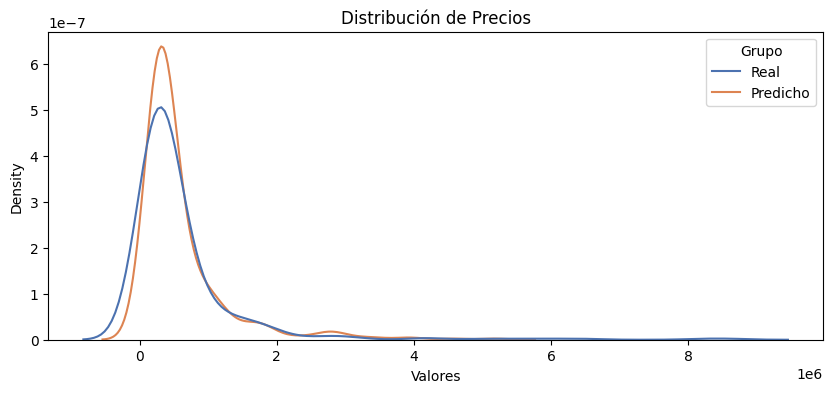

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos3['precio']), pd.Series(y_test_pred)]),
                   'Grupo': ['Real'] * len(y_test_pred) + ['Predicho'] * len(y_test_pred)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.05,0.1,0.25,0.5,0.75,0.9,0.95])

Valores                                                             \
           count           mean            std           min             5%   
Grupo                                                                         
Predicho   429.0  599700.429148  668924.162838  56331.556356  117912.799544   
Real       429.0  598105.953427  923647.061937   5000.000000   60200.000000   

                                                                     \
                    10%            25%            50%           75%   
Grupo                                                                 
Predicho  162500.225439  277469.099058  344592.111978  636536.56443   
Real      108800.000000  220000.000000  325000.000000  590000.00000   

                                                    
                   90%           95%           max  
Grupo                                               
Predicho  1.218876e+06  1.829283e+06  5.165474e+06  
Real      1.209000e+06  1.800000e+06  8.625000e+06

In [ ]:
df = pd.DataFrame({'importancia':rf.feature_importances_}, index = X.columns)
df.sort_values(by='importancia', ascending=False)

,importancia
mts2,0.549540
cnt_habit_ph_med,0.083769
parqueos,0.068571
CANT_SUPERMERCADO,0.058501
banos,0.057579
hogares_sin_agua,0.055093
hogares_lectura,0.041759
CANT_HOSPITAL,0.036168
hogares_techo_lamina,0.015577
miembros_ph_avg,0.012809


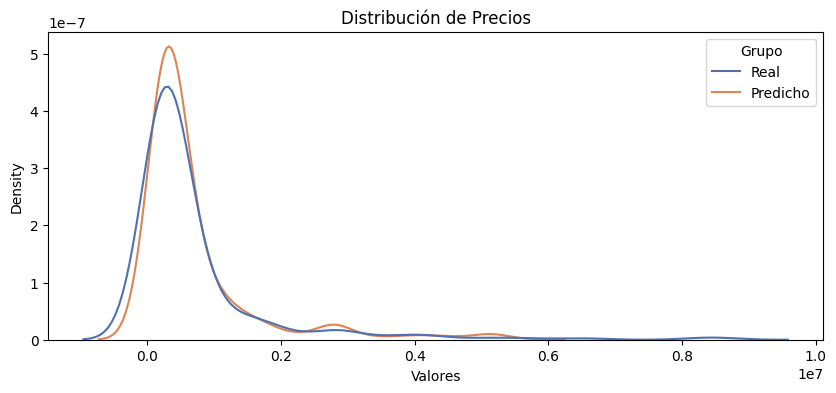

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(y), pd.Series(y_train_pred)]),
                   'Grupo': ['Real'] * len(y) + ['Predicho'] * len(y)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

Valores                                                            \
           count           mean           std           min            10%   
Grupo                                                                        
Predicho   577.0  706514.454192  9.283574e+05  56331.556356  151693.383899   
Real       577.0  701489.510088  1.141316e+06   5000.000000   96661.562532   

                                                                      \
                    20%            30%            40%            50%   
Grupo                                                                  
Predicho  225878.702436  293479.943214  311143.191364  354414.070684   
Real      160000.000000  229800.000000  285000.000000  325000.000000   

                                                                     \
                    60%            70%            80%           90%   
Grupo                                                                 
Predicho  451839.911451  573181.690698  844453.217829  1.609984e+06   
Real      403000.000000  507914.016675  795000.000000  1.620000e+06   

                                      
                  100%           max  
Grupo                                 
Predicho  5.469661e+06  5.469661e+06  
Real      8.625000e+06  8.625000e+06

In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)


In [ ]:
analisis_deciles(y, y_train_pred)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,5000.000,95498.000,72.414,27.586,0.000
1,2,97437.271,160000.000,54.237,45.763,0.000
2,3,160852.431,229000.000,39.286,60.714,0.000
3,4,230000.000,285000.000,20.312,79.688,0.000
4,5,286290.000,325000.000,11.321,86.792,1.887
5,6,325884.914,400000.000,16.071,83.929,0.000
6,7,405000.000,504892.521,10.345,87.931,1.724
7,8,520000.000,795000.000,20.690,62.069,17.241
8,9,800000.000,1600000.000,21.053,64.912,14.035
9,10,1650000.000,8625000.000,3.448,79.310,17.241


In [ ]:
analisis_deciles(datos3['precio'], y_test_pred2)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,5000.000,108000.000,83.721,16.279,0.000
1,2,109000.000,175000.000,60.465,39.535,0.000
2,3,178000.000,250000.000,30.435,69.565,0.000
3,4,254587.000,288000.000,9.756,90.244,0.000
4,5,290000.000,325000.000,9.302,88.372,2.326
5,6,330000.000,400000.000,20.455,79.545,0.000
6,7,405000.000,500000.000,4.762,92.857,2.381
7,8,520000.000,695000.000,23.256,58.140,18.605
8,9,697000.000,1200000.000,24.390,58.537,17.073
9,10,1245000.000,8625000.000,6.977,67.442,25.581


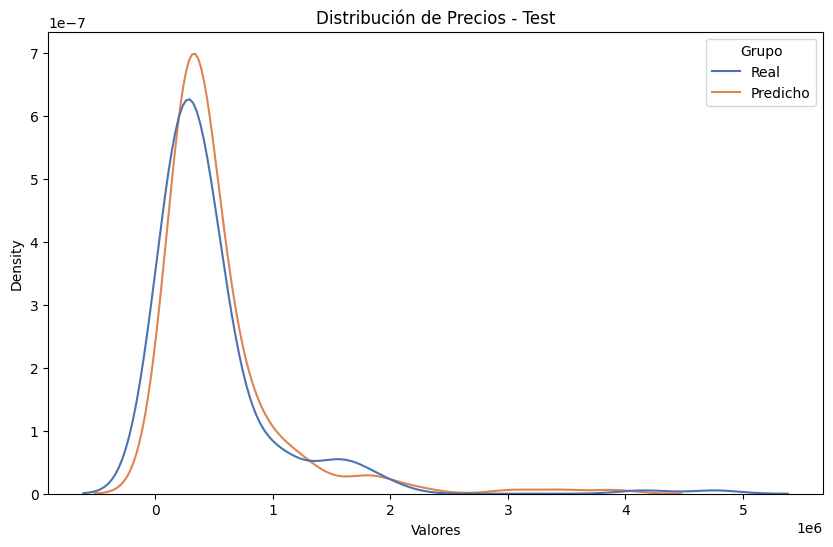

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos2['precio']), pd.Series(y_test_pred)]),
                   'Grupo': ['Real'] * len(y_test_pred) + ['Predicho'] * len(y_test_pred)})

plt.figure(figsize=(10, 6))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios - Test')
plt.show()

# Random Fores 2

Probamos normalizando la variable respuesta

In [20]:

from sklearn.preprocessing import  PowerTransformer


pt = PowerTransformer( standardize=True)

y_t = pt.fit_transform(y.to_frame())

In [ ]:
params = {
    'n_estimators': 200,
    'max_depth': 10,
    'min_samples_split': 10
}
rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
rf.fit(X, y_t)
y_train_pred = pt.inverse_transform(rf.predict(X).reshape(-1, 1)).flatten()
metricas(y.reset_index(drop=True), y_train_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 649362.4346384106,
 'MAPE': 0.3509915073895862,
 'R2': 0.6757230079881347,
 'Mediana_ErrorAbs': np.float64(0.15476857466456115),
 'Pct_Error<0.3': np.float64(0.7383015597920277)}

In [ ]:
df = pd.DataFrame({'importancia':rf.feature_importances_}, index = X.columns)
df.sort_values(by='importancia', ascending=False)

,importancia
mts2,0.420
banos,0.283
hogares_lectura,0.070
miembros_ph_avg,0.044
CANT_SUPERMERCADO,0.035
parqueos,0.030
CANT_HOSPITAL,0.024
zona_avg,0.018
hogares_techo_lamina,0.018
hogares_sin_agua,0.016


### Resultados train smote

In [ ]:

y_train_pred = pt.inverse_transform(rf.predict(X).reshape(-1, 1)).flatten()
metricas(y.reset_index(drop=True), y_train_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 649362.4346384105,
 'MAPE': 0.3509915073895862,
 'R2': 0.6757230079881348,
 'Mediana_ErrorAbs': np.float64(0.15476857466456115),
 'Pct_Error<0.3': np.float64(0.7383015597920277)}

In [ ]:
analisis_deciles(y.reset_index(drop=True), y_train_pred)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,5000.000,95498.000,53.448,46.552,0.000
1,2,97437.271,160000.000,30.508,66.102,3.390
2,3,160852.431,229000.000,19.643,75.000,5.357
3,4,230000.000,285000.000,10.938,89.062,0.000
4,5,286290.000,325000.000,1.887,90.566,7.547
5,6,325884.914,400000.000,8.929,89.286,1.786
6,7,405000.000,504892.521,10.345,77.586,12.069
7,8,520000.000,795000.000,6.897,70.690,22.414
8,9,800000.000,1600000.000,12.281,59.649,28.070
9,10,1650000.000,8625000.000,0.000,74.138,25.862


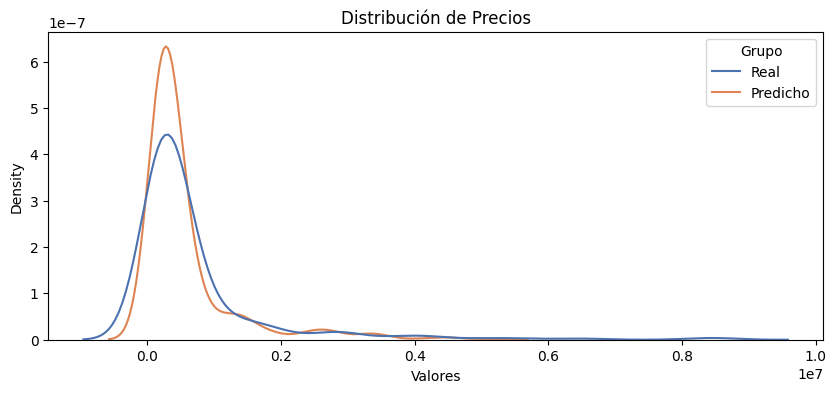

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(y), pd.Series(y_train_pred)]),
                   'Grupo': ['Real'] * len(y_train_pred) + ['Predicho'] * len(y_train_pred)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.05,0.1,0.25,0.5,0.75,0.9,0.95])

Valores                                                        \
           count       mean         std       min        5%        10%   
Grupo                                                                    
Predicho 577.000 574188.269  739318.927 49875.195 75545.681 112544.689   
Real     577.000 701489.510 1141315.613  5000.000 60045.792  96661.563   

                                                                               
                25%        50%        75%         90%         95%         max  
Grupo                                                                          
Predicho 210732.787 311804.919 541457.935 1370235.954 2387403.917 5075757.330  
Real     195000.000 325000.000 623636.233 1620000.000 2830981.836 8625000.000

## Resultados train sin smote

In [ ]:

y_test_pred = pt.inverse_transform(rf.predict(datos3[atributos]).reshape(-1, 1)).flatten()
metricas(datos3['precio'], y_test_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 629663.427790991,
 'MAPE': 0.39076219280211655,
 'R2': 0.5341797592531328,
 'Mediana_ErrorAbs': np.float64(0.1668152038084734),
 'Pct_Error<0.3': np.float64(0.710955710955711)}

In [ ]:
analisis_deciles(datos3['precio'], y_test_pred)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,5000.000,108000.000,62.791,37.209,0.000
1,2,109000.000,175000.000,41.860,53.488,4.651
2,3,178000.000,250000.000,10.870,82.609,6.522
3,4,254587.000,288000.000,7.317,92.683,0.000
4,5,290000.000,325000.000,2.326,90.698,6.977
5,6,330000.000,400000.000,11.364,86.364,2.273
6,7,405000.000,500000.000,4.762,78.571,16.667
7,8,520000.000,695000.000,6.977,72.093,20.930
8,9,697000.000,1200000.000,17.073,58.537,24.390
9,10,1245000.000,8625000.000,0.000,58.140,41.860


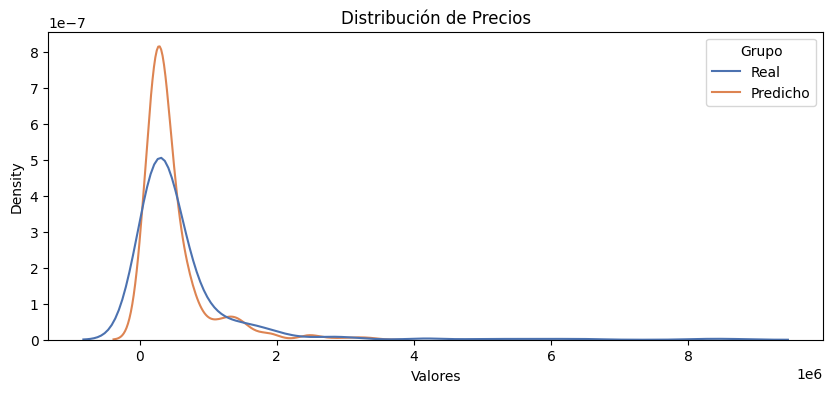

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos3['precio']), pd.Series(y_test_pred)]),
                   'Grupo': ['Real'] * len(y_test_pred) + ['Predicho'] * len(y_test_pred)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.05,0.1,0.25,0.5,0.75,0.9,0.95])

Valores                                                       \
           count       mean        std       min        5%        10%   
Grupo                                                                   
Predicho 429.000 478660.664 481486.007 49875.195 76735.461 131999.203   
Real     429.000 598105.953 923647.062  5000.000 60200.000 108800.000   

                                                                               
                25%        50%        75%         90%         95%         max  
Grupo                                                                          
Predicho 242499.301 314007.726 531101.930 1047249.068 1426410.029 3373941.747  
Real     220000.000 325000.000 590000.000 1209000.000 1800000.000 8625000.000

## Resultados test

In [ ]:

y_test_pred2 = pt.inverse_transform(rf.predict(datos2[atributos]).reshape(-1, 1)).flatten()
metricas(datos2['precio'], y_test_pred2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 372052.6923201704,
 'MAPE': 0.6095615712369917,
 'R2': 0.5991761457273284,
 'Mediana_ErrorAbs': np.float64(0.2547530958944071),
 'Pct_Error<0.3': np.float64(0.5760869565217391)}

In [ ]:
analisis_deciles(datos2['precio'], y_test_pred2)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,10000.000,84000.000,68.421,31.579,0.000
1,2,85000.000,165000.000,43.478,52.174,4.348
2,3,172680.000,228723.000,38.462,53.846,7.692
3,4,235000.000,289000.000,5.263,94.737,0.000
4,5,290000.000,325000.000,20.000,75.000,5.000
5,6,326500.000,380000.000,0.000,88.235,11.765
6,7,384900.000,475000.000,16.667,61.111,22.222
7,8,480000.000,600000.000,10.526,47.368,42.105
8,9,612000.000,1050000.000,0.000,47.059,52.941
9,10,1100000.000,4760000.000,5.263,26.316,68.421


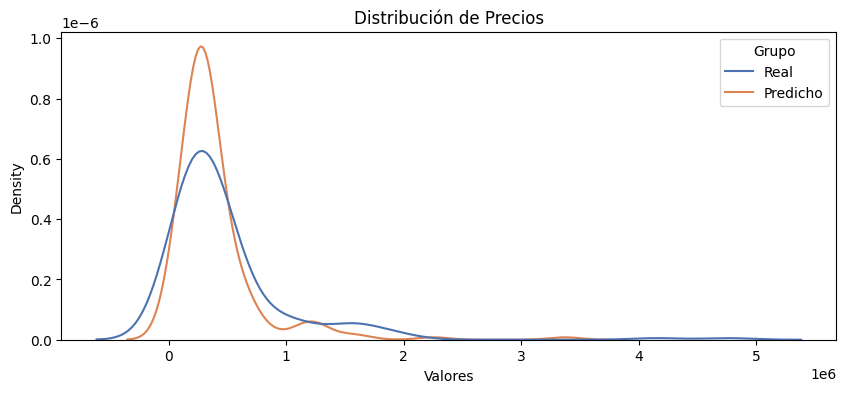

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos2['precio']), pd.Series(y_test_pred2)]),
                   'Grupo': ['Real'] * len(y_test_pred2) + ['Predicho'] * len(y_test_pred2)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.05,0.1,0.25,0.5,0.75,0.9,0.95])

Valores                                                       \
           count       mean        std       min        5%        10%   
Grupo                                                                   
Predicho 184.000 391399.280 379714.938 51493.823 78407.274 119727.549   
Real     184.000 490758.224 589265.532 10000.000 60000.000  84300.000   

                                                                               
                25%        50%        75%         90%         95%         max  
Grupo                                                                          
Predicho 225832.713 298403.632 405123.500  658236.389 1186146.287 3373941.747  
Real     184875.000 325000.000 525000.000 1085000.000 1560000.000 4760000.000

# Random Forest 3 - optimizado

Optimizamos el modelo.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.3 MB/s eta 0:00:00


In [ ]:

import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer
from sklearn.utils import parallel_backend
import numpy as np

In [ ]:
def opt_rf_pt( trial):

    # ==============================
    # PowerTransformer para Y
    # ==============================
    pt_y = PowerTransformer()
    y_train_t = pt_y.fit_transform(y.values.reshape(-1,1)).flatten()

    # ==============================
    # Hiperparámetros RF
    # ==============================
    rf_params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 5, 100),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 100),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 25),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

    rf_regressor = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **rf_params
    )

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    r2_scores = []


    for train_idx, valid_idx in kf.split(X):

        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr_t, y_val = y_train_t[train_idx], y.iloc[valid_idx]

        # Entrenar en la escala transformada
        rf_regressor.fit(X_tr, y_tr_t)

        # Predecir en la escala transformada
        y_pred_t = rf_regressor.predict(X_val)

        # Invertir la transformación
        y_pred = pt_y.inverse_transform(y_pred_t.reshape(-1,1)).flatten()

        # Calcular R² en escala original
        r2 = r2_score(y_val, y_pred)
        r2_scores.append(r2)


    r2_mean = np.median(r2_scores) # usamos mediana xq promedio esta demasiado afectado ...

    # Optuna minimiza → devolvemos negativo del R² promedio
    return -r2_mean

In [ ]:
def opt_rf_pt(trial):

    # ==============================
    # PowerTransformer para Y
    # ==============================
    pt_y = PowerTransformer()
    y_train_t = pt_y.fit_transform(y.values.reshape(-1,1)).flatten()

    # ==============================
    # Hiperparámetros RF
    # ==============================
    rf_params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 5, 100),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 100),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 25),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

    rf_regressor = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **rf_params
    )

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    metric_scores = []   # almacenará el % de errores < 30%


    # ==============================
    # Cross-validation manual
    # ==============================
    for train_idx, valid_idx in kf.split(X):

        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr_t, y_val = y_train_t[train_idx], y.iloc[valid_idx]

        # Entrenar en la escala transformada
        rf_regressor.fit(X_tr, y_tr_t)

        # Predecir en la escala transformada
        y_pred_t = rf_regressor.predict(X_val)

        # Invertir transformación a escala original
        y_pred = pt_y.inverse_transform(y_pred_t.reshape(-1,1)).flatten()

        # ==============================
        # Métrica personalizada
        # Porcentaje de APE < 30%
        # ==============================
        ape = np.abs((y_val - y_pred) / y_val)
        pct_below_30 = np.mean(ape < 0.30)

        metric_scores.append(pct_below_30)

    # Usamos mediana para mayor estabilidad
    metric_mean = np.median(metric_scores)

    # Optuna maximiza → devolvemos valor positivo
    return metric_mean

In [ ]:
study_lgm = optuna.create_study(direction='minimize')

[I 2025-11-22 03:30:36,630] A new study created in memory with name: no-name-fd9b6e50-22ea-45a1-883c-5944f74dd561


In [ ]:

study_lgm.optimize(opt_rf_pt, n_trials=500)

[I 2025-11-22 03:30:42,449] Trial 0 finished with value: 0.49740932642487046 and parameters: {'n_estimators': 561, 'max_depth': 28, 'min_samples_split': 36, 'min_samples_leaf': 15, 'bootstrap': True}. Best is trial 0 with value: 0.49740932642487046.
[I 2025-11-22 03:30:45,924] Trial 1 finished with value: 0.5077720207253886 and parameters: {'n_estimators': 504, 'max_depth': 32, 'min_samples_split': 5, 'min_samples_leaf': 14, 'bootstrap': True}. Best is trial 0 with value: 0.49740932642487046.
[I 2025-11-22 03:30:47,783] Trial 2 finished with value: 0.4322916666666667 and parameters: {'n_estimators': 310, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 19, 'bootstrap': False}. Best is trial 2 with value: 0.4322916666666667.
[I 2025-11-22 03:30:48,617] Trial 3 finished with value: 0.4635416666666667 and parameters: {'n_estimators': 118, 'max_depth': 6, 'min_samples_split': 75, 'min_samples_leaf': 19, 'bootstrap': True}. Best is trial 2 with value: 0.4322916666666667.
[I 2025

In [ ]:
lgm_params = study_lgm.best_params
print(lgm_params)


{'n_estimators': 632, 'max_depth': 44, 'min_samples_split': 100, 'min_samples_leaf': 10, 'bootstrap': False}


In [ ]:
# optimizacion con r2 promedio
lgm_params = {'n_estimators': 972, 'max_depth': 32, 'min_samples_split': 4, 'min_samples_leaf': 1, 'bootstrap': True}

In [ ]:
# optimizacion con r2 mediana
lgm_params = {'n_estimators': 919, 'max_depth': 87, 'min_samples_split': 10, 'min_samples_leaf': 2, 'bootstrap': False}

In [ ]:
# optimizacion con rango30 promedio
lgm_params = {'n_estimators': 632, 'max_depth': 44, 'min_samples_split': 100, 'min_samples_leaf': 10, 'bootstrap': False}

## Modelo optimizado

In [ ]:

rf = RandomForestRegressor(**lgm_params, random_state=42, n_jobs=-1)
rf.fit(X, y_t)
y_train_pred = pt.inverse_transform(rf.predict(X).reshape(-1, 1)).flatten()
metricas(y.reset_index(drop=True), y_train_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 618574.4255158817,
 'MAPE': 0.3845464863985841,
 'R2': 0.7057437240758366,
 'Mediana_ErrorAbs': np.float64(0.15192254270219246),
 'Pct_Error<0.3': np.float64(0.7261698440207972)}

In [ ]:
df = pd.DataFrame({'importancia':rf.feature_importances_}, index = X.columns)
df.sort_values(by='importancia', ascending=False)

,importancia
mts2,0.422795
banos,0.331426
hogares_lectura,0.069311
CANT_SUPERMERCADO,0.041224
hogares_techo_lamina,0.041160
zona_avg,0.027406
CANT_HOSPITAL,0.014564
hogares_sin_agua,0.014314
parqueos,0.011313
tipo_vivienda_avg,0.010052


### Resultados train sin smote

In [ ]:

y_test_pred = pt.inverse_transform(rf.predict(datos3[atributos]).reshape(-1, 1)).flatten()
metricas(datos3['precio'], y_test_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 603369.7785767165,
 'MAPE': 0.4044287855781054,
 'R2': 0.572271169719045,
 'Mediana_ErrorAbs': np.float64(0.17687354195790567),
 'Pct_Error<0.3': np.float64(0.7062937062937062)}

In [ ]:
analisis_deciles(datos3['precio'], y_test_pred)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,5000.0,108000.0,48.837209,48.837209,2.325581
1,2,109000.0,175000.0,34.883721,62.790698,2.325581
2,3,178000.0,250000.0,6.521739,78.260870,15.217391
3,4,254587.0,288000.0,2.439024,95.121951,2.439024
4,5,290000.0,325000.0,9.302326,83.720930,6.976744
5,6,330000.0,400000.0,11.363636,81.818182,6.818182
6,7,405000.0,500000.0,16.666667,64.285714,19.047619
7,8,520000.0,695000.0,9.302326,69.767442,20.930233
8,9,697000.0,1200000.0,17.073171,70.731707,12.195122
9,10,1245000.0,8625000.0,6.976744,51.162791,41.860465


In [ ]:
analisis_agrupado(datos3['precio'], y_test_pred, datos3['zona2'])

/tmp/ipython-input-2737312186.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('grupo').apply(lambda x: pd.Series({


,grupo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,0,18000.0,8208000.0,16.326531,65.306122,18.367347
1,1,12000.0,6500000.0,13.362069,75.000000,11.637931
2,2,5000.0,8625000.0,20.945946,65.540541,13.513514


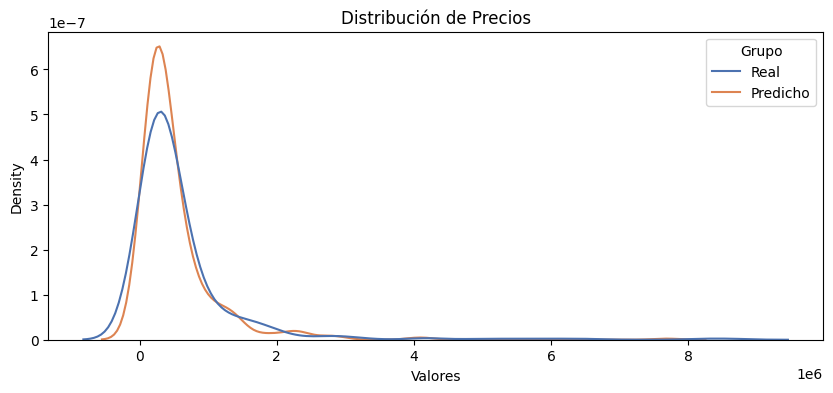

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos3['precio']), pd.Series(y_test_pred)]),
                   'Grupo': ['Real'] * len(y_test_pred) + ['Predicho'] * len(y_test_pred)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.05,0.1,0.25,0.5,0.75,0.9,0.95])

Valores                                                           \
           count           mean            std          min            5%   
Grupo                                                                       
Predicho   429.0  518566.277479  639042.116758  21600.64444  79913.927875   
Real       429.0  598105.953427  923647.061937   5000.00000  60200.000000   

                                                                     \
                   10%            25%            50%            75%   
Grupo                                                                 
Predicho  121797.28731  223771.093692  311398.410462  616020.602336   
Real      108800.00000  220000.000000  325000.000000  590000.000000   

                                                    
                   90%           95%           max  
Grupo                                               
Predicho  1.110404e+06  1.394842e+06  7.676985e+06  
Real      1.209000e+06  1.800000e+06  8.625000e+06

### Resultados test

In [ ]:

y_test_pred2 = pt.inverse_transform(rf.predict(datos2[atributos]).reshape(-1, 1)).flatten()
metricas(datos2['precio'], y_test_pred2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 354949.34261947894,
 'MAPE': 0.5243767997474003,
 'R2': 0.6351810332584742,
 'Mediana_ErrorAbs': np.float64(0.3069843161631598),
 'Pct_Error<0.3': np.float64(0.4891304347826087)}

In [ ]:
analisis_deciles(datos2['precio'], y_test_pred2)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,10000.0,84000.0,78.947368,21.052632,0.000000
1,2,85000.0,165000.0,39.130435,52.173913,8.695652
2,3,172680.0,228723.0,61.538462,23.076923,15.384615
3,4,235000.0,289000.0,26.315789,63.157895,10.526316
4,5,290000.0,325000.0,25.000000,60.000000,15.000000
5,6,326500.0,380000.0,0.000000,88.235294,11.764706
6,7,384900.0,475000.0,22.222222,55.555556,22.222222
7,8,480000.0,600000.0,15.789474,52.631579,31.578947
8,9,612000.0,1050000.0,11.764706,29.411765,58.823529
9,10,1100000.0,4760000.0,10.526316,36.842105,52.631579


In [ ]:
analisis_agrupado(datos2['precio'], y_test_pred2, datos2['zona2'])

/tmp/ipython-input-2737312186.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('grupo').apply(lambda x: pd.Series({


,grupo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,0,60000.0,4760000.0,24.000000,36.000000,40.000000
1,1,82000.0,1800000.0,28.865979,55.670103,15.463918
2,2,10000.0,1980000.0,30.645161,43.548387,25.806452


In [ ]:
datos2['zona2'].value_counts()

,count
zona2,
1,97
2,62
0,25


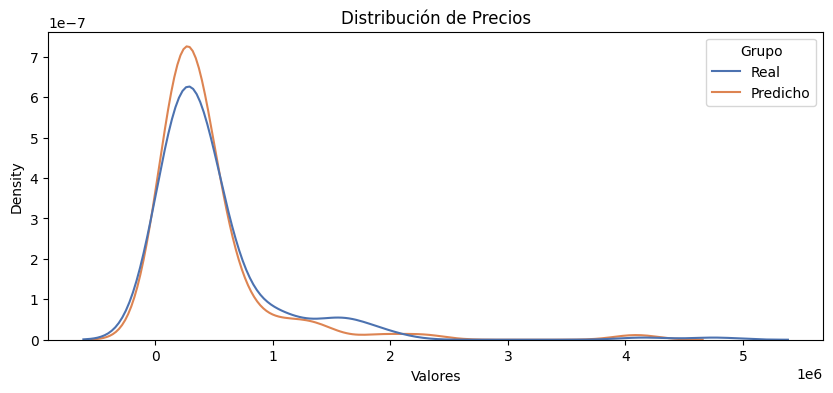

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos2['precio']), pd.Series(y_test_pred2)]),
                   'Grupo': ['Real'] * len(y_test_pred2) + ['Predicho'] * len(y_test_pred2)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.05,0.1,0.25,0.5,0.75,0.9,0.95])

Valores                                                           \
           count           mean            std          min            5%   
Grupo                                                                       
Predicho   184.0  441461.278352  536211.997729  21600.64444  85164.723275   
Real       184.0  490758.223913  589265.531656  10000.00000  60000.000000   

                                                                      \
                    10%            25%            50%            75%   
Grupo                                                                  
Predicho  104445.622509  196142.118806  300195.530212  454755.728873   
Real       84300.000000  184875.000000  325000.000000  525000.000000   

                                                    
                   90%           95%           max  
Grupo                                               
Predicho  8.341237e+05  1.301939e+06  4.090448e+06  
Real      1.085000e+06  1.560000e+06  4.760000e+06

# Random Forest 4 - pesos

Agregamos otro hiperparámetro a optimizar: los pesos!

Optimizacion respecto a r2 mediana

In [ ]:
def opt_rf_pt( trial):

    # ==============================
    # PowerTransformer para Y
    # ==============================
    pt_y = PowerTransformer()
    y_train_t = pt_y.fit_transform(y.values.reshape(-1,1)).flatten()

    # ==============================
    # Hiperparámetros RF
    # ==============================
    #rf_params = {
    #    "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
    #    "max_depth": trial.suggest_int("max_depth", 5, 100),
    #    "min_samples_split": trial.suggest_int("min_samples_split", 2, 100),
    #    "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 25),
    #    "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    #}
    # Mantieniendo fijos los hiperparametros de la ultima corrida.
    rf_params = {'n_estimators': 919, 'max_depth': 87, 'min_samples_split': 10, 'min_samples_leaf': 2, 'bootstrap': False}

    rf_regressor = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **rf_params
    )

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    r2_scores = []
    umbral_bajo = trial.suggest_int("umbral_bajo", 15000, 30000)
    peso_bajo = trial.suggest_float("peso_bajo", 1.0, 25.0, step=0.5)


    for train_idx, valid_idx in kf.split(X):

        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr_t, y_val = y_train_t[train_idx], y.iloc[valid_idx]

        y_revision = y.iloc[train_idx]
        pesos = np.where(y_revision < umbral_bajo, peso_bajo, 1.0)

        # Entrenar en la escala transformada
        rf_regressor.fit(X_tr, y_tr_t, sample_weight=pesos)

        # Predecir en la escala transformada
        y_pred_t = rf_regressor.predict(X_val)

        # Invertir la transformación
        y_pred = pt_y.inverse_transform(y_pred_t.reshape(-1,1)).flatten()

        # Calcular R² en escala original
        r2 = r2_score(y_val, y_pred)
        r2_scores.append(r2)


    r2_mean = np.mean(r2_scores) 
    # Optuna minimiza → devolvemos negativo del R² promedio
    return -r2_mean

In [ ]:
def opt_rf_pt( trial):

    # ==============================
    # PowerTransformer para Y
    # ==============================
    pt_y = PowerTransformer()
    y_train_t = pt_y.fit_transform(y.values.reshape(-1,1)).flatten()

    # ==============================
    # Hiperparámetros RF
    # ==============================
    #rf_params = {
    #    "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
    #    "max_depth": trial.suggest_int("max_depth", 5, 100),
    #    "min_samples_split": trial.suggest_int("min_samples_split", 2, 100),
    #    "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 25),
    #    "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    #}
    # Mantieniendo fijos los hiperparametros de la ultima corrida.
    rf_params = {'n_estimators': 919, 'max_depth': 87, 'min_samples_split': 10, 'min_samples_leaf': 2, 'bootstrap': False}

    rf_regressor = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **rf_params
    )

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    r2_scores = []
    umbral_bajo = trial.suggest_int("umbral_bajo", 15000, 30000)
    peso_bajo = trial.suggest_float("peso_bajo", 1.0, 25.0, step=0.5)


    for train_idx, valid_idx in kf.split(X):

        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr_t, y_val = y_train_t[train_idx], y.iloc[valid_idx]

        y_revision = y.iloc[train_idx]
        pesos = np.where(y_revision < umbral_bajo, peso_bajo, 1.0)

        # Entrenar en la escala transformada
        rf_regressor.fit(X_tr, y_tr_t, sample_weight=pesos)

        # Predecir en la escala transformada
        y_pred_t = rf_regressor.predict(X_val)

        # Invertir la transformación
        y_pred = pt_y.inverse_transform(y_pred_t.reshape(-1,1)).flatten()

        # Calcular R² en escala original
        r2 = r2_score(y_val, y_pred)
        r2_scores.append(r2)


    r2_mean = np.median(r2_scores) # usamos mediana xq promedio esta demasiado afectado ...

    # Optuna minimiza → devolvemos negativo del R² promedio
    return -r2_mean

In [ ]:
def opt_rf_pt( trial):

    # ==============================
    # PowerTransformer para Y
    # ==============================
    pt_y = PowerTransformer()
    y_train_t = pt_y.fit_transform(y.values.reshape(-1,1)).flatten()

    # ==============================
    # Hiperparámetros RF
    # ==============================
    rf_params = {
        "n_estimators": trial.suggest_int("n_estimators", 800, 2000),
        "max_depth": trial.suggest_int("max_depth", 75, 150),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 25),
        "bootstrap": trial.suggest_categorical("bootstrap", [ False])
    }
    # Mantieniendo fijos los hiperparametros de la ultima corrida.
    #rf_params = {'n_estimators': 919, 'max_depth': 87, 'min_samples_split': 10, 'min_samples_leaf': 2, 'bootstrap': False}

    rf_regressor = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **rf_params
    )

    r2_scores = []
    umbral_bajo = trial.suggest_int("umbral_bajo", 15000, 30000)
    peso_bajo = trial.suggest_float("peso_bajo", 1.0, 25.0, step=0.5)

    pesos = np.where(y < umbral_bajo, peso_bajo, 1.0)
    rf_regressor.fit(X, y_train_t, sample_weight=pesos)
    y_pred_t = rf_regressor.predict(datos2[atributos])
    y_pred = pt_y.inverse_transform(y_pred_t.reshape(-1,1)).flatten()

    r2_mean = r2_score(datos2['precio'], y_pred)

    ## sobre train, penalizando el sobreajuste
    y_pred_t = rf_regressor.predict(datos3[atributos])
    y_pred2 = pt_y.inverse_transform(y_pred_t.reshape(-1,1)).flatten()

    r2_mean_2 = r2_score(datos3['precio'], y_pred2)

    optimizar = r2_mean_2 - (r2_mean_2 - r2_mean)

    # Optuna minimiza → devolvemos negativo del R² promedio
    return -optimizar

In [ ]:
study_lgm = optuna.create_study(direction='minimize')

[I 2025-12-25 23:37:54,018] A new study created in memory with name: no-name-fc727e35-78e0-4cbc-aeae-9adaf6aef748


In [ ]:
study_lgm.optimize(opt_rf_pt, n_trials=500)

[I 2025-12-25 23:38:01,120] Trial 0 finished with value: -0.34921497201045915 and parameters: {'n_estimators': 961, 'max_depth': 102, 'min_samples_split': 25, 'min_samples_leaf': 22, 'bootstrap': False, 'umbral_bajo': 16113, 'peso_bajo': 23.5}. Best is trial 0 with value: -0.34921497201045915.
[I 2025-12-25 23:38:04,451] Trial 1 finished with value: -0.33571778173807887 and parameters: {'n_estimators': 1298, 'max_depth': 142, 'min_samples_split': 44, 'min_samples_leaf': 20, 'bootstrap': False, 'umbral_bajo': 24414, 'peso_bajo': 24.0}. Best is trial 0 with value: -0.34921497201045915.
[I 2025-12-25 23:38:08,941] Trial 2 finished with value: -0.6320191264800717 and parameters: {'n_estimators': 1128, 'max_depth': 125, 'min_samples_split': 6, 'min_samples_leaf': 7, 'bootstrap': False, 'umbral_bajo': 22701, 'peso_bajo': 18.0}. Best is trial 2 with value: -0.6320191264800717.
[I 2025-12-25 23:38:15,247] Trial 3 finished with value: -0.5375456656641423 and parameters: {'n_estimators': 1991, '

In [ ]:
lgm_params = study_lgm.best_params
print(lgm_params)

{'n_estimators': 1660, 'max_depth': 133, 'min_samples_split': 6, 'min_samples_leaf': 3, 'bootstrap': False, 'umbral_bajo': 19184, 'peso_bajo': 11.0}


## Modelo optimizado

In [21]:
# Segundo, buenos resultados
pesos = np.where(y < 17925, 12.5, 1.0)
lgm_params = {'n_estimators': 1195, 'max_depth': 143, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}

In [22]:
atributos = ['mts2', 'banos', 'miembros_ph_avg', 'hogares_lectura', 'CANT_HOSPITAL', 'parqueos', 'CANT_SUPERMERCADO', 'tipo_vivienda_avg', 'tipo_vivienda_le', 'hogares_techo_lamina', 'hogares_sin_agua', 'dormitorios', 'zona_avg', 'cnt_habit_ph_med', 'zona_le']
atributos = ['mts2', 'banos', 'miembros_ph_avg', 'hogares_lectura', 'CANT_HOSPITAL', 'parqueos', 'CANT_SUPERMERCADO', 'tipo_vivienda_avg', 'hogares_techo_lamina', 'hogares_sin_agua', 'dormitorios'
]


In [23]:
len(atributos)

11

In [24]:
import pickle

with open("modelo_rf.pkl", "wb") as f:
    pickle.dump(rf, f)

NameError: name 'rf' is not defined

In [25]:

rf = RandomForestRegressor(**lgm_params, random_state=42, n_jobs=-1)
rf.fit(X[atributos], y_t, sample_weight=pesos)
y_train_pred = pt.inverse_transform(rf.predict(X[atributos]).reshape(-1, 1)).flatten()
metricas(y.reset_index(drop=True), y_train_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 462064.16992984305,
 'MAPE': 0.2293720921057505,
 'R2': 0.8358101146600905,
 'Mediana_ErrorAbs': np.float64(0.13846812161949978),
 'Pct_Error<0.3': np.float64(0.7746967071057193)}

In [26]:
df = pd.DataFrame({'importancia':rf.feature_importances_}, index = X[atributos].columns)
df.sort_values(by='importancia', ascending=False)

,importancia
mts2,0.690743
banos,0.176412
miembros_ph_avg,0.034866
hogares_lectura,0.022322
CANT_HOSPITAL,0.019096
tipo_vivienda_avg,0.014628
parqueos,0.013265
CANT_SUPERMERCADO,0.011336
hogares_techo_lamina,0.007219
hogares_sin_agua,0.005552


### Resultados train sin smote

In [47]:

y_test_pred = pt.inverse_transform(rf.predict(datos3[atributos]).reshape(-1, 1)).flatten()
metricas(datos3['precio'], y_test_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 434571.1089034236,
 'MAPE': 0.2470774265166379,
 'R2': 0.7781174658195757,
 'Mediana_ErrorAbs': np.float64(0.15070406355297247),
 'Pct_Error<0.3': np.float64(0.7552447552447552)}

In [48]:
analisis_deciles(datos3['precio'], y_test_pred)

/tmp/ipython-input-575148819.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,43.0000,"5,000.0000","108,000.0000",41.8605,51.1628,6.9767
1,2,43.0000,"109,000.0000","175,000.0000",25.5814,67.4419,6.9767
2,3,46.0000,"178,000.0000","250,000.0000",6.5217,89.1304,4.3478
3,4,41.0000,"254,587.0000","288,000.0000",7.3171,87.8049,4.8780
4,5,43.0000,"290,000.0000","325,000.0000",6.9767,88.3721,4.6512
5,6,44.0000,"330,000.0000","400,000.0000",13.6364,84.0909,2.2727
6,7,42.0000,"405,000.0000","500,000.0000",4.7619,90.4762,4.7619
7,8,43.0000,"520,000.0000","695,000.0000",16.2791,60.4651,23.2558
8,9,41.0000,"697,000.0000","1,200,000.0000",12.1951,68.2927,19.5122
9,10,43.0000,"1,245,000.0000","8,625,000.0000",9.3023,67.4419,23.2558


In [50]:
analisis_deciles(datos3['precio'], y_test_pred, n_deciles=5)

/tmp/ipython-input-575148819.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,86.0000,"5,000.0000","175,000.0000",33.7209,59.3023,6.9767
1,2,87.0000,"178,000.0000","288,000.0000",6.8966,88.5057,4.5977
2,3,87.0000,"290,000.0000","400,000.0000",10.3448,86.2069,3.4483
3,4,85.0000,"405,000.0000","695,000.0000",10.5882,75.2941,14.1176
4,5,84.0000,"697,000.0000","8,625,000.0000",10.7143,67.8571,21.4286


In [49]:
analisis_deciles(datos3['precio'], y_test_pred, tipo = 'pred')

/tmp/ipython-input-575148819.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,44.0000,"5,000.0000","1,200,000.0000",22.7273,54.5455,22.7273
1,2,44.0000,"75,000.0000","315,000.0000",13.6364,79.5455,6.8182
2,3,43.0000,"75,000.0000","610,000.0000",16.2791,74.4186,9.3023
3,4,43.0000,"150,000.0000","570,000.0000",2.3256,95.3488,2.3256
4,5,44.0000,"170,826.0000","531,716.8400",9.0909,86.3636,4.5455
5,6,40.0000,"129,000.0000","697,000.0000",10.0000,77.5000,12.5000
6,7,42.0000,"233,200.0000","700,000.0000",9.5238,80.9524,9.5238
7,8,46.0000,"310,000.0000","1,550,000.0000",15.2174,76.0870,8.6957
8,9,43.0000,"100,000.0000","3,200,000.0000",23.2558,60.4651,16.2791
9,10,40.0000,"650,000.0000","8,625,000.0000",22.5000,70.0000,7.5000


In [51]:
analisis_deciles(datos3['precio'], y_test_pred, n_deciles=5,tipo = 'pred')

/tmp/ipython-input-575148819.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,88.0000,"5,000.0000","1,200,000.0000",18.1818,67.0455,14.7727
1,2,86.0000,"75,000.0000","610,000.0000",9.3023,84.8837,5.8140
2,3,84.0000,"129,000.0000","697,000.0000",9.5238,82.1429,8.3333
3,4,88.0000,"233,200.0000","1,550,000.0000",12.5000,78.4091,9.0909
4,5,83.0000,"100,000.0000","8,625,000.0000",22.8916,65.0602,12.0482


In [29]:
analisis_agrupado(datos3['precio'], y_test_pred, datos3['zona2'])

/tmp/ipython-input-2737312186.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('grupo').apply(lambda x: pd.Series({


,grupo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,0,18000.0,8625000.0,12.765957,81.914894,5.319149
1,1,12000.0,6500000.0,12.500000,78.017241,9.482759
2,2,5000.0,3200000.0,20.388350,64.077670,15.533981


In [30]:
datos3.zona2.value_counts()

,count
zona2,
1,232
2,103
0,94


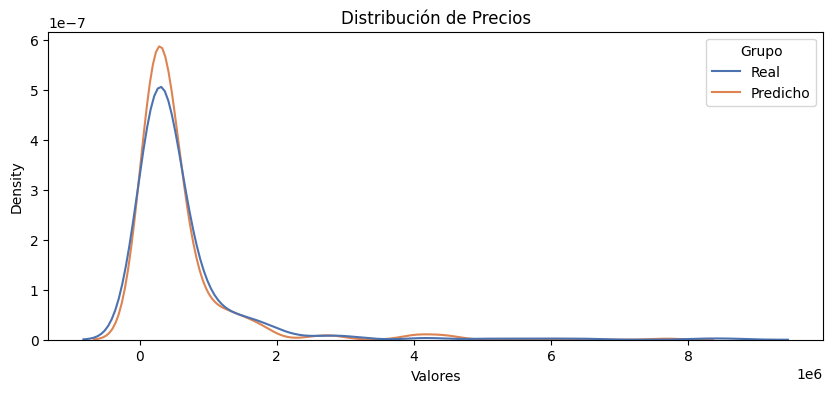

In [31]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos3['precio']), pd.Series(y_test_pred)]),
                   'Grupo': ['Real'] * len(y_test_pred) + ['Predicho'] * len(y_test_pred)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [32]:

pd.set_option('display.float_format', '{:,.4f}'.format)

In [33]:
df.groupby('Grupo').describe(percentiles = [0.05,0.1,0.25,0.5,0.75,0.9,0.95])

Valores                                                   \
            count         mean          std        min          5%   
Grupo                                                                
Predicho 429.0000 551,687.1299 757,572.2324 8,408.4698 52,665.1594   
Real     429.0000 598,105.9534 923,647.0619 5,000.0000 60,200.0000   

                                                                             \
                  10%          25%          50%          75%            90%   
Grupo                                                                         
Predicho 101,605.1921 215,841.0055 321,593.5030 553,792.9230 1,211,392.9194   
Real     108,800.0000 220,000.0000 325,000.0000 590,000.0000 1,209,000.0000   

                                        
                    95%            max  
Grupo                                   
Predicho 1,703,135.1972 7,676,984.8629  
Real     1,800,000.0000 8,625,000.0000

### Resultados test

In [52]:

y_test_pred2 = pt.inverse_transform(rf.predict(datos2[atributos]).reshape(-1, 1)).flatten()
metricas(datos2['precio'], y_test_pred2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 316597.72063227283,
 'MAPE': 0.7522088568480317,
 'R2': 0.7097580225891258,
 'Mediana_ErrorAbs': np.float64(0.2539582393547044),
 'Pct_Error<0.3': np.float64(0.5706521739130435)}

In [53]:
analisis_deciles(datos2['precio'], y_test_pred2)

/tmp/ipython-input-575148819.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,19.0000,"10,000.0000","84,000.0000",63.1579,21.0526,15.7895
1,2,23.0000,"85,000.0000","165,000.0000",34.7826,34.7826,30.4348
2,3,13.0000,"172,680.0000","228,723.0000",46.1538,38.4615,15.3846
3,4,19.0000,"235,000.0000","289,000.0000",15.7895,68.4211,15.7895
4,5,20.0000,"290,000.0000","325,000.0000",25.0000,70.0000,5.0000
5,6,17.0000,"326,500.0000","380,000.0000",0.0000,88.2353,11.7647
6,7,18.0000,"384,900.0000","475,000.0000",11.1111,72.2222,16.6667
7,8,19.0000,"480,000.0000","600,000.0000",5.2632,68.4211,26.3158
8,9,17.0000,"612,000.0000","1,050,000.0000",5.8824,58.8235,35.2941
9,10,19.0000,"1,100,000.0000","4,760,000.0000",0.0000,52.6316,47.3684


In [54]:
analisis_deciles(datos2['precio'], y_test_pred2, n_deciles=5)

/tmp/ipython-input-575148819.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,42.0000,"10,000.0000","165,000.0000",47.6190,28.5714,23.8095
1,2,32.0000,"172,680.0000","289,000.0000",28.1250,56.2500,15.6250
2,3,37.0000,"290,000.0000","380,000.0000",13.5135,78.3784,8.1081
3,4,37.0000,"384,900.0000","600,000.0000",8.1081,70.2703,21.6216
4,5,36.0000,"612,000.0000","4,760,000.0000",2.7778,55.5556,41.6667


In [55]:
analisis_deciles(datos2['precio'], y_test_pred2, tipo = 'pred')

/tmp/ipython-input-575148819.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,20.0000,"16,000.0000","1,200,000.0000",15.0000,25.0000,60.0000
1,2,17.0000,"73,000.0000","1,800,000.0000",23.5294,35.2941,41.1765
2,3,19.0000,"50,000.0000","410,000.0000",42.1053,47.3684,10.5263
3,4,19.0000,"235,000.0000","1,700,000.0000",0.0000,78.9474,21.0526
4,5,17.0000,"125,000.0000","750,000.0000",17.6471,70.5882,11.7647
5,6,20.0000,"82,000.0000","1,050,000.0000",20.0000,55.0000,25.0000
6,7,19.0000,"60,000.0000","700,000.0000",15.7895,73.6842,10.5263
7,8,20.0000,"10,000.0000","1,500,000.0000",30.0000,60.0000,10.0000
8,9,15.0000,"103,000.0000","1,600,000.0000",20.0000,53.3333,26.6667
9,10,18.0000,"290,000.0000","4,760,000.0000",22.2222,72.2222,5.5556


In [56]:
analisis_deciles(datos2['precio'], y_test_pred2, tipo = 'pred', n_deciles=5)

/tmp/ipython-input-575148819.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,37.0000,"16,000.0000","1,800,000.0000",18.9189,29.7297,51.3514
1,2,38.0000,"50,000.0000","1,700,000.0000",21.0526,63.1579,15.7895
2,3,37.0000,"82,000.0000","1,050,000.0000",18.9189,62.1622,18.9189
3,4,39.0000,"10,000.0000","1,500,000.0000",23.0769,66.6667,10.2564
4,5,33.0000,"103,000.0000","4,760,000.0000",21.2121,63.6364,15.1515


In [57]:
analisis_agrupado(datos2['precio'], y_test_pred2, datos2['zona2'])

/tmp/ipython-input-2737312186.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('grupo').apply(lambda x: pd.Series({


,grupo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,0,"25,000.0000","4,760,000.0000",16.2162,48.6486,35.1351
1,1,"82,000.0000","1,800,000.0000",17.5258,70.1031,12.3711
2,2,"10,000.0000","1,980,000.0000",30.0000,38.0000,32.0000


In [58]:
datos2['zona2'].value_counts()

,count
zona2,
1,97
2,50
0,37


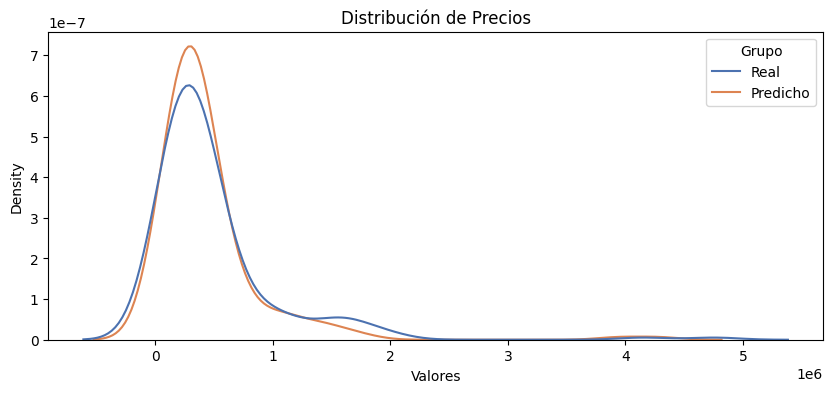

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos2['precio']), pd.Series(y_test_pred2)]),
                   'Grupo': ['Real'] * len(y_test_pred2) + ['Predicho'] * len(y_test_pred2)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.05,0.1,0.25,0.5,0.75,0.9,0.95])

Valores                                                    \
            count         mean          std         min          5%   
Grupo                                                                 
Predicho 184.0000 442,849.0593 505,652.9402  8,408.4698 52,665.1594   
Real     184.0000 490,758.2239 589,265.5317 10,000.0000 60,000.0000   

                                                                             \
                  10%          25%          50%          75%            90%   
Grupo                                                                         
Predicho 100,079.3675 213,786.4863 318,207.9284 476,959.8778   846,956.8732   
Real      84,300.0000 184,875.0000 325,000.0000 525,000.0000 1,085,000.0000   

                                        
                    95%            max  
Grupo                                   
Predicho 1,199,057.8849 4,283,531.8307  
Real     1,560,000.0000 4,760,000.0000

# Random Forest 5 - pesos

Lo mismo que el 4 pero la optimizacion es sobre la mediana del error.

In [ ]:
def opt_rf_pt( trial):

    # ==============================
    # PowerTransformer para Y
    # ==============================
    pt_y = PowerTransformer()
    y_train_t = pt_y.fit_transform(y.values.reshape(-1,1)).flatten()

    # ==============================
    # Hiperparámetros RF
    # ==============================
    rf_params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 5, 100),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 100),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 25),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

    rf_regressor = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **rf_params
    )

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    r2_scores = []
    umbral_bajo = trial.suggest_int("umbral_bajo", 15000, 30000)
    peso_bajo = trial.suggest_float("peso_bajo", 1.0, 25.0, step=0.5)


    for train_idx, valid_idx in kf.split(X):

        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr_t, y_val = y_train_t[train_idx], y.iloc[valid_idx]

        y_revision = y.iloc[train_idx]
        pesos = np.where(y_revision < umbral_bajo, peso_bajo, 1.0)

        # Entrenar en la escala transformada
        rf_regressor.fit(X_tr, y_tr_t, sample_weight=pesos)

        # Predecir en la escala transformada
        y_pred_t = rf_regressor.predict(X_val)

        # Invertir la transformación
        y_pred = pt_y.inverse_transform(y_pred_t.reshape(-1,1)).flatten()

        ape = np.abs((y_val - y_pred) / y_val)
        mediaanaa = np.median(ape)

        r2_scores.append(mediaanaa)


    r2_mean = np.median(r2_scores) # usamos mediana xq promedio esta demasiado afectado ...

    # Optuna minimiza → devolvemos negativo del R² promedio
    return r2_mean

In [ ]:
def opt_rf_pt( trial):

    # ==============================
    # PowerTransformer para Y
    # ==============================
    pt_y = PowerTransformer()
    y_train_t = pt_y.fit_transform(y.values.reshape(-1,1)).flatten()

    # ==============================
    # Hiperparámetros RF
    # ==============================
    #rf_params = {
    #    "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
    #    "max_depth": trial.suggest_int("max_depth", 5, 100),
    #    "min_samples_split": trial.suggest_int("min_samples_split", 2, 100),
    #    "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 25),
    #    "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    #}
    rf_params = {'n_estimators': 919, 'max_depth': 87, 'min_samples_split': 10, 'min_samples_leaf': 2, 'bootstrap': False}


    rf_regressor = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **rf_params
    )

    r2_scores = []
    umbral_bajo = trial.suggest_int("umbral_bajo", 15000, 30000)
    peso_bajo = trial.suggest_float("peso_bajo", 1.0, 25.0, step=0.5)

    pesos = np.where(y < umbral_bajo, peso_bajo, 1.0)
    rf_regressor.fit(X, y_train_t, sample_weight=pesos)
    y_pred_t = rf_regressor.predict(datos3[atributos])
    y_pred = pt_y.inverse_transform(y_pred_t.reshape(-1,1)).flatten()
    ape = np.abs((datos3['precio'] - y_pred) / datos3['precio'])
    mediaanaa = np.median(ape)



    r2_mean = mediaanaa

    # Optuna minimiza → devolvemos negativo del R² promedio
    return r2_mean

In [ ]:
def opt_rf_pt( trial):

    # ==============================
    # PowerTransformer para Y
    # ==============================
    pt_y = PowerTransformer()
    y_train_t = pt_y.fit_transform(y.values.reshape(-1,1)).flatten()

    # ==============================
    # Hiperparámetros RF
    # ==============================
    #rf_params = {
    #    "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
    #    "max_depth": trial.suggest_int("max_depth", 5, 100),
    #    "min_samples_split": trial.suggest_int("min_samples_split", 2, 100),
    #    "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 25),
    #    "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    #}
    rf_params = {'n_estimators': 919, 'max_depth': 87, 'min_samples_split': 10, 'min_samples_leaf': 2, 'bootstrap': False}


    rf_regressor = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **rf_params
    )

    r2_scores = []
    umbral_bajo = trial.suggest_int("umbral_bajo", 15000, 30000)
    peso_bajo = trial.suggest_float("peso_bajo", 1.0, 25.0, step=0.5)

    pesos = np.where(y < umbral_bajo, peso_bajo, 1.0)
    rf_regressor.fit(X, y_train_t, sample_weight=pesos)
    y_pred_t = rf_regressor.predict(datos2[atributos])
    y_pred = pt_y.inverse_transform(y_pred_t.reshape(-1,1)).flatten()
    ape = np.abs((datos2['precio'] - y_pred) / datos2['precio'])
    mediaanaa = np.median(ape)



    r2_mean = mediaanaa

    # Optuna minimiza → devolvemos negativo del R² promedio
    return r2_mean

In [ ]:
study_lgm = optuna.create_study(direction='minimize')

[I 2025-12-16 04:05:40,266] A new study created in memory with name: no-name-52d4469a-884f-4292-a595-72524c974149


In [ ]:
study_lgm.optimize(opt_rf_pt, n_trials=100)

[I 2025-12-16 04:05:43,696] Trial 0 finished with value: 0.30383782732103803 and parameters: {'umbral_bajo': 25230, 'peso_bajo': 3.0}. Best is trial 0 with value: 0.30383782732103803.
[I 2025-12-16 04:05:47,200] Trial 1 finished with value: 0.2760462067267817 and parameters: {'umbral_bajo': 18614, 'peso_bajo': 9.5}. Best is trial 1 with value: 0.2760462067267817.
[I 2025-12-16 04:05:51,718] Trial 2 finished with value: 0.2772126948496627 and parameters: {'umbral_bajo': 18372, 'peso_bajo': 14.0}. Best is trial 1 with value: 0.2760462067267817.
[I 2025-12-16 04:05:54,999] Trial 3 finished with value: 0.28524936375762233 and parameters: {'umbral_bajo': 24369, 'peso_bajo': 18.5}. Best is trial 1 with value: 0.2760462067267817.
[W 2025-12-16 04:05:57,745] Trial 4 failed with parameters: {'umbral_bajo': 16604, 'peso_bajo': 20.5} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", l

KeyboardInterrupt: 

In [ ]:
lgm_params = study_lgm.best_params
print(lgm_params)

In [ ]:
study_lgm = optuna.create_study(direction='minimize')

[I 2025-12-16 03:33:11,146] A new study created in memory with name: no-name-59cd0c9e-6bbf-42d1-871a-4bb9bdb087df


In [ ]:
study_lgm.optimize(opt_rf_pt, n_trials=500)

[I 2025-12-16 03:33:20,715] Trial 0 finished with value: 0.14572139256697414 and parameters: {'umbral_bajo': 19780, 'peso_bajo': 4.0}. Best is trial 0 with value: 0.14572139256697414.
[I 2025-12-16 03:33:24,953] Trial 1 finished with value: 0.15329002630105695 and parameters: {'umbral_bajo': 26391, 'peso_bajo': 19.5}. Best is trial 0 with value: 0.14572139256697414.
[I 2025-12-16 03:33:28,633] Trial 2 finished with value: 0.15329002630105695 and parameters: {'umbral_bajo': 27874, 'peso_bajo': 19.0}. Best is trial 0 with value: 0.14572139256697414.
[I 2025-12-16 03:33:32,220] Trial 3 finished with value: 0.15848905080828118 and parameters: {'umbral_bajo': 19754, 'peso_bajo': 12.5}. Best is trial 0 with value: 0.14572139256697414.
[I 2025-12-16 03:33:35,741] Trial 4 finished with value: 0.14245031418509668 and parameters: {'umbral_bajo': 26182, 'peso_bajo': 6.0}. Best is trial 4 with value: 0.14245031418509668.
[I 2025-12-16 03:33:40,504] Trial 5 finished with value: 0.15862603379018314 

In [ ]:
lgm_params = study_lgm.best_params
print(lgm_params)

{'umbral_bajo': 26182, 'peso_bajo': 6.0}


## Modelo optimizado

In [ ]:
pesos = np.where(y < 26182, 6, 1.0)

In [ ]:
lgm_params = {'n_estimators': 1195, 'max_depth': 143, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}

In [ ]:

rf = RandomForestRegressor(**lgm_params, random_state=42, n_jobs=-1)
rf.fit(X, y_t, sample_weight=pesos)
y_train_pred = pt.inverse_transform(rf.predict(X).reshape(-1, 1)).flatten()
metricas(y.reset_index(drop=True), y_train_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 479140.604373272,
 'MAPE': 0.1597369786688431,
 'R2': 0.8234499820561337,
 'Mediana_ErrorAbs': np.float64(0.07614829274317107),
 'Pct_Error<0.3': np.float64(0.8648180242634316)}

In [ ]:
df = pd.DataFrame({'importancia':rf.feature_importances_}, index = X.columns)
df.sort_values(by='importancia', ascending=False)

,importancia
mts2,0.433701
banos,0.175407
miembros_ph_avg,0.129193
hogares_lectura,0.055278
tipo_vivienda_avg,0.038849
parqueos,0.036228
CANT_SUPERMERCADO,0.031483
CANT_HOSPITAL,0.024672
hogares_techo_lamina,0.016304
zona_avg,0.015878


### Resultados train sin smote

In [40]:

y_test_pred = pt.inverse_transform(rf.predict(datos3[atributos]).reshape(-1, 1)).flatten()
metricas(datos3['precio'], y_test_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 434571.1089034236,
 'MAPE': 0.2470774265166379,
 'R2': 0.7781174658195757,
 'Mediana_ErrorAbs': np.float64(0.15070406355297247),
 'Pct_Error<0.3': np.float64(0.7552447552447552)}

In [41]:
analisis_deciles(datos3['precio'], y_test_pred)

/tmp/ipython-input-570948373.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,43.0000,"5,000.0000","108,000.0000",41.8605,51.1628,6.9767
1,2,43.0000,"109,000.0000","175,000.0000",25.5814,67.4419,6.9767
2,3,46.0000,"178,000.0000","250,000.0000",6.5217,89.1304,4.3478
3,4,41.0000,"254,587.0000","288,000.0000",7.3171,87.8049,4.8780
4,5,43.0000,"290,000.0000","325,000.0000",6.9767,88.3721,4.6512
5,6,44.0000,"330,000.0000","400,000.0000",13.6364,84.0909,2.2727
6,7,42.0000,"405,000.0000","500,000.0000",4.7619,90.4762,4.7619
7,8,43.0000,"520,000.0000","695,000.0000",16.2791,60.4651,23.2558
8,9,41.0000,"697,000.0000","1,200,000.0000",12.1951,68.2927,19.5122
9,10,43.0000,"1,245,000.0000","8,625,000.0000",9.3023,67.4419,23.2558


In [42]:
analisis_deciles(datos3['precio'], y_test_pred, n_deciles=5)

/tmp/ipython-input-570948373.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,86.0000,"5,000.0000","175,000.0000",33.7209,59.3023,6.9767
1,2,87.0000,"178,000.0000","288,000.0000",6.8966,88.5057,4.5977
2,3,87.0000,"290,000.0000","400,000.0000",10.3448,86.2069,3.4483
3,4,85.0000,"405,000.0000","695,000.0000",10.5882,75.2941,14.1176
4,5,84.0000,"697,000.0000","8,625,000.0000",10.7143,67.8571,21.4286


In [ ]:
analisis_agrupado(datos3['precio'], y_test_pred, datos3['zona2'])

/tmp/ipython-input-2737312186.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('grupo').apply(lambda x: pd.Series({


,grupo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,0,18000.0,8208000.0,18.367347,73.469388,8.163265
1,1,12000.0,6500000.0,5.172414,90.948276,3.879310
2,2,5000.0,8625000.0,12.837838,79.054054,8.108108


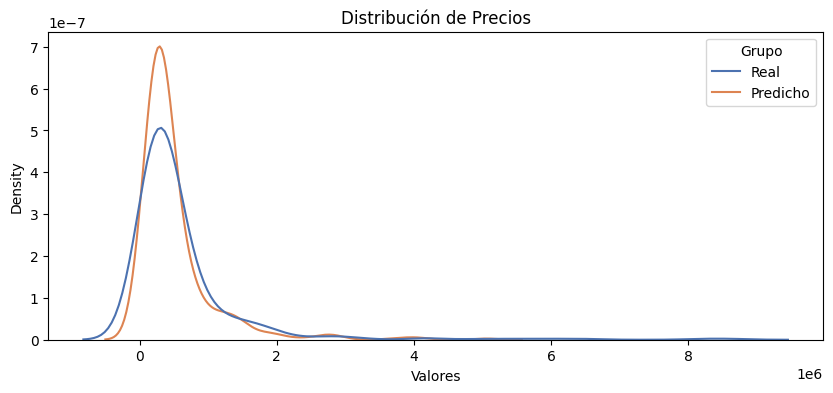

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos3['precio']), pd.Series(y_test_pred)]),
                   'Grupo': ['Real'] * len(y_test_pred) + ['Predicho'] * len(y_test_pred)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.05,0.1,0.25,0.5,0.75,0.9,0.95])

Valores                                                            \
           count           mean            std           min            5%   
Grupo                                                                        
Predicho   429.0  508289.192888  582764.744369  21156.762496  64090.881257   
Real       429.0  598105.953427  923647.061937   5000.000000  60200.000000   

                                                                      \
                    10%            25%            50%            75%   
Grupo                                                                  
Predicho  111959.932097  231357.085735  323099.690234  533631.979887   
Real      108800.000000  220000.000000  325000.000000  590000.000000   

                                                    
                   90%           95%           max  
Grupo                                               
Predicho  1.136788e+06  1.501965e+06  5.050547e+06  
Real      1.209000e+06  1.800000e+06  8.625000e+06

### Resultados test

In [43]:

y_test_pred2 = pt.inverse_transform(rf.predict(datos2[atributos]).reshape(-1, 1)).flatten()
metricas(datos2['precio'], y_test_pred2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


{'RMSE': 316597.72063227283,
 'MAPE': 0.7522088568480317,
 'R2': 0.7097580225891258,
 'Mediana_ErrorAbs': np.float64(0.2539582393547044),
 'Pct_Error<0.3': np.float64(0.5706521739130435)}

In [44]:
analisis_deciles(datos2['precio'], y_test_pred2)

/tmp/ipython-input-570948373.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,19.0000,"10,000.0000","84,000.0000",63.1579,21.0526,15.7895
1,2,23.0000,"85,000.0000","165,000.0000",34.7826,34.7826,30.4348
2,3,13.0000,"172,680.0000","228,723.0000",46.1538,38.4615,15.3846
3,4,19.0000,"235,000.0000","289,000.0000",15.7895,68.4211,15.7895
4,5,20.0000,"290,000.0000","325,000.0000",25.0000,70.0000,5.0000
5,6,17.0000,"326,500.0000","380,000.0000",0.0000,88.2353,11.7647
6,7,18.0000,"384,900.0000","475,000.0000",11.1111,72.2222,16.6667
7,8,19.0000,"480,000.0000","600,000.0000",5.2632,68.4211,26.3158
8,9,17.0000,"612,000.0000","1,050,000.0000",5.8824,58.8235,35.2941
9,10,19.0000,"1,100,000.0000","4,760,000.0000",0.0000,52.6316,47.3684


In [45]:
analisis_deciles(datos2['precio'], y_test_pred2,n_deciles=5)


/tmp/ipython-input-570948373.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,conteo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,42.0000,"10,000.0000","165,000.0000",47.6190,28.5714,23.8095
1,2,32.0000,"172,680.0000","289,000.0000",28.1250,56.2500,15.6250
2,3,37.0000,"290,000.0000","380,000.0000",13.5135,78.3784,8.1081
3,4,37.0000,"384,900.0000","600,000.0000",8.1081,70.2703,21.6216
4,5,36.0000,"612,000.0000","4,760,000.0000",2.7778,55.5556,41.6667


In [ ]:
analisis_agrupado(datos2['precio'], y_test_pred2, datos2['zona2'])

/tmp/ipython-input-2737312186.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('grupo').apply(lambda x: pd.Series({


,grupo,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,0,60000.0,4760000.0,16.000000,52.000000,32.000000
1,1,82000.0,1800000.0,21.649485,62.886598,15.463918
2,2,10000.0,1980000.0,20.967742,51.612903,27.419355


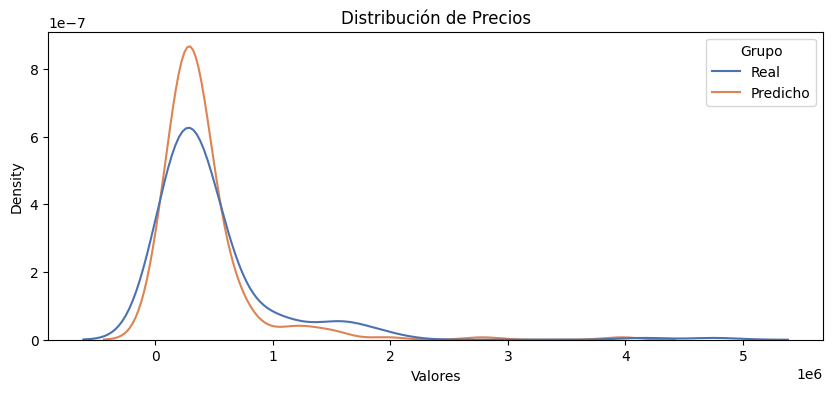

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos2['precio']), pd.Series(y_test_pred2)]),
                   'Grupo': ['Real'] * len(y_test_pred2) + ['Predicho'] * len(y_test_pred2)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.05,0.1,0.25,0.5,0.75,0.9,0.95])

Valores                                                            \
           count           mean            std           min            5%   
Grupo                                                                        
Predicho   184.0  406693.367052  433545.511515  21156.762496  65442.787418   
Real       184.0  490758.223913  589265.531656  10000.000000  60000.000000   

                                                                      \
                    10%            25%            50%            75%   
Grupo                                                                  
Predicho  124499.568084  213477.618531  310040.825965  414741.887557   
Real       84300.000000  184875.000000  325000.000000  525000.000000   

                                                    
                   90%           95%           max  
Grupo                                               
Predicho  6.778560e+05  1.165721e+06  3.963991e+06  
Real      1.085000e+06  1.560000e+06  4.760000e+06

#